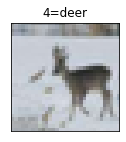

In [1]:
import numpy as np
np.random.seed(1)
from tensorflow.random import set_seed
set_seed(1)

import tensorflow as tf
import numpy as np
from keras.utils import np_utils
from keras.datasets import cifar10
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
import matplotlib.pyplot as plt
from tensorflow.keras.layers import SpatialDropout2D, Dropout
from keras.layers import BatchNormalization
from tensorflow.keras import optimizers

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

LabelMeanings=['0=plane','1=auto','2=bird','3=cat','4=deer','5=dog','6=frog','7=horse','8=ship','9=truck']

i=20
plt.figure(figsize=(2,2))
plt.imshow(x_train[i])  
plt.title(LabelMeanings[y_train[i][0]])
plt.xticks([])
plt.yticks([])

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0


y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)


In [2]:
#model without dropout 
model = Sequential(name='CIFAR10_CNN')

model = Sequential()
model.add(Conv2D(filters=10, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
#model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
#model.add(Dropout(0.2))


model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
#model.add(Dropout(0.3))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
#model.add(Dropout(0.4))


model.add(Flatten())
model.add(Dense(units=256, activation='relu'))
model.add(BatchNormalization())
#model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax'))

opt = optimizers.SGD(learning_rate=0.001, momentum=.85)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

hist = model.fit(x_train, y_train,
                 epochs=10,
                 batch_size=64,
                 validation_data=(x_test, y_test))

Epoch 1/10
782/782 [==============================] - 449s 572ms/step - loss: 1.5135 - accuracy: 0.4681 - val_loss: 1.2559 - val_accuracy: 0.5525
Epoch 2/10
782/782 [==============================] - 458s 585ms/step - loss: 1.0368 - accuracy: 0.6322 - val_loss: 1.1689 - val_accuracy: 0.5996
Epoch 3/10
782/782 [==============================] - 468s 599ms/step - loss: 0.8305 - accuracy: 0.7091 - val_loss: 1.0517 - val_accuracy: 0.6334
Epoch 4/10
782/782 [==============================] - 447s 572ms/step - loss: 0.6796 - accuracy: 0.7638 - val_loss: 0.9150 - val_accuracy: 0.6862
Epoch 5/10
782/782 [==============================] - 473s 605ms/step - loss: 0.5435 - accuracy: 0.8132 - val_loss: 0.9065 - val_accuracy: 0.6951
Epoch 6/10
782/782 [==============================] - 458s 586ms/step - loss: 0.4281 - accuracy: 0.8555 - val_loss: 0.9101 - val_accuracy: 0.6952
Epoch 7/10
782/782 [==============================] - 475s 608ms/step - loss: 0.3170 - accuracy: 0.8974 - val_loss: 0.9074 -

1/1 [==============================] - 20s 20s/step - loss: 1.0094 - accuracy: 0.7088
Final Test set Loss: 1.009368896484375
Final Test set Accuracy: 70.88000178337097 %
Final Test set Misclassification Rate: 29.11999821662903 %


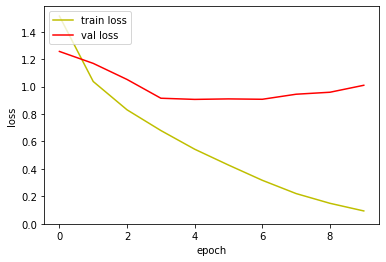

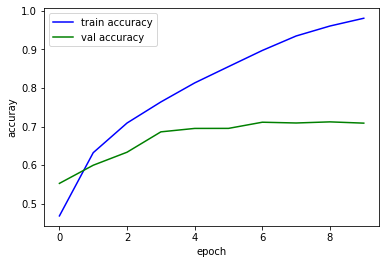

In [3]:
plt.figure()
plt.plot(hist.history['loss'], 'y', label='train loss')
plt.plot(hist.history['val_loss'], 'r', label='val loss')
plt.ylim(bottom=0)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='upper left')

plt.figure()
plt.plot(hist.history['accuracy'], 'b', label='train accuracy')
plt.plot(hist.history['val_accuracy'], 'g', label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuray')
plt.legend(loc='upper left')

loss_and_acc = model.evaluate(x_test, y_test, batch_size=np.shape(x_test)[0])
print('Final Test set Loss:',loss_and_acc[0])
print('Final Test set Accuracy:',100*loss_and_acc[1],'%')
print('Final Test set Misclassification Rate:',100*(1-loss_and_acc[1]),'%')

In [4]:
#model w/ dropout

model = Sequential(name='CIFAR10_CNN')

model = Sequential()
model.add(Conv2D(filters=10, kernel_size=3, padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.1))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.2))


model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.4))


model.add(Flatten())
model.add(Dense(units=256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(units=10, activation='softmax'))

opt = optimizers.SGD(learning_rate=0.001, momentum=.85)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

hist = model.fit(x_train, y_train,
                 epochs=10,
                 batch_size=64,
                 validation_data=(x_test, y_test))

Epoch 1/10
782/782 [==============================] - 494s 629ms/step - loss: 2.1704 - accuracy: 0.3119 - val_loss: 1.4971 - val_accuracy: 0.4575
Epoch 2/10
782/782 [==============================] - 455s 582ms/step - loss: 1.5654 - accuracy: 0.4421 - val_loss: 1.3960 - val_accuracy: 0.4995
Epoch 3/10
782/782 [==============================] - 446s 571ms/step - loss: 1.3426 - accuracy: 0.5150 - val_loss: 1.4719 - val_accuracy: 0.4908
Epoch 4/10
782/782 [==============================] - 487s 623ms/step - loss: 1.2009 - accuracy: 0.5676 - val_loss: 1.0606 - val_accuracy: 0.6165
Epoch 5/10
782/782 [==============================] - 473s 604ms/step - loss: 1.1127 - accuracy: 0.6018 - val_loss: 1.1009 - val_accuracy: 0.6033
Epoch 6/10
782/782 [==============================] - 485s 620ms/step - loss: 1.0463 - accuracy: 0.6261 - val_loss: 0.9845 - val_accuracy: 0.6432
Epoch 7/10
782/782 [==============================] - 491s 628ms/step - loss: 0.9912 - accuracy: 0.6473 - val_loss: 0.8752 -

1/1 [==============================] - 20s 20s/step - loss: 0.8410 - accuracy: 0.7040
Final Test set Loss: 0.8410367369651794
Final Test set Accuracy: 70.39999961853027 %
Final Test set Misclassification Rate: 29.600000381469727 %


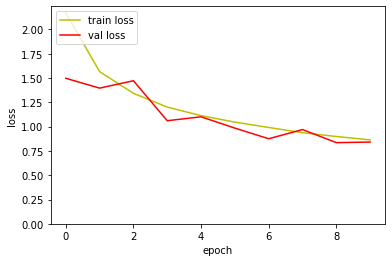

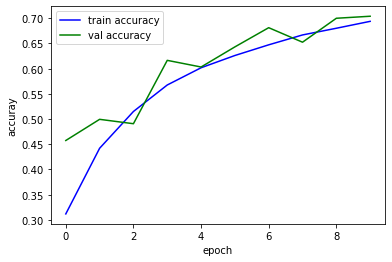

In [5]:
plt.figure()
plt.plot(hist.history['loss'], 'y', label='train loss')
plt.plot(hist.history['val_loss'], 'r', label='val loss')
plt.ylim(bottom=0)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(loc='upper left')

plt.figure()
plt.plot(hist.history['accuracy'], 'b', label='train accuracy')
plt.plot(hist.history['val_accuracy'], 'g', label='val accuracy')
plt.xlabel('epoch')
plt.ylabel('accuray')
plt.legend(loc='upper left')

loss_and_acc = model.evaluate(x_test, y_test, batch_size=np.shape(x_test)[0])
print('Final Test set Loss:',loss_and_acc[0])
print('Final Test set Accuracy:',100*loss_and_acc[1],'%')
print('Final Test set Misclassification Rate:',100*(1-loss_and_acc[1]),'%')